## Um estudo sobre o mercado de ações utilizando LSTM e GRU

De acordo com a proposta apresentada em sala de aula, este trabalho tem como objetivo realizar um estudo utilizando modelos de redes neurais recorrentes, especificamente **LSTM** e **GRU**, para a previsão de preços de ações no mercado financeiro.

Para a condução deste estudo, foi sugerida a utilização de **3** a **4** ações pertencentes a setores distintos, mas que apresentassem comportamentos semelhantes ao longo do período de **2019** a **2025**.

Diante disso, foi realizada uma análise exploratória inicial com o objetivo de identificar possíveis correlações entre diferentes ativos. Para isso, optou-se por coletar dados de todas as ações que compõem o índice **S&P 500**, utilizando a biblioteca __yfinance__. A partir desses dados, foram analisadas correlações entre ativos de diferentes setores, com o intuito de embasar a escolha das ações que comporiam o portfólio analisado.

#### O que é LSTM (Long Short-Term Memory)

A **LSTM** é um tipo de rede neural recorrente **(RNN)** muito utilizada para trabalhar com dados sequenciais, como séries temporais. Isso inclui, por exemplo, preços de ações ao longo do tempo.

Diferente de modelos mais simples, a LSTM consegue “lembrar” informações importantes por longos períodos e “esquecer” o que não é relevante. Isso é feito por meio de mecanismos internos chamados de “portas”, que controlam o fluxo de informação dentro da rede.

Na prática, isso torna a **LSTM** especialmente útil para identificar padrões em dados que evoluem com o tempo, como tendências no mercado financeiro.

#### O que é GRU (Gated Recurrent Unit)

A **GRU** é uma variação da **LSTM**, também utilizada para dados sequenciais. Ela foi criada com o objetivo de ser mais simples e mais rápida, mantendo um desempenho semelhante.

Assim como a **LSTM**, a **GRU** também possui mecanismos que controlam o que deve ser lembrado ou esquecido, porém com uma estrutura menos complexa.

Por ser mais leve computacionalmente, a **GRU** pode ser uma boa alternativa em situações onde se deseja reduzir o tempo de treinamento sem perder muita qualidade nos resultados.

#### O que é S&P 500

O **S&P 500** é um dos principais índices do mercado financeiro dos Estados Unidos. Ele reúne aproximadamente 500 das maiores empresas listadas em bolsa no país, abrangendo diversos setores da economia, como tecnologia, saúde, indústria e financeiro.

Esse índice é amplamente utilizado como referência para avaliar o desempenho geral do mercado de ações. Quando se diz que “o mercado subiu” ou “o mercado caiu”, muitas vezes isso está relacionado ao comportamento do **S&P 500**.

No contexto deste trabalho, o **S&P 500** foi utilizado como base para seleção de ativos, permitindo analisar empresas de diferentes setores e identificar possíveis correlações entre elas.

A partir deste ponto, será apresentada, por meio do notebook (arquivo .ipynb), a linha de raciocínio adotada, bem como as decisões tomadas ao longo do desenvolvimento do projeto.

- Bliotecas a serem utilizadas no projeto e suas respectivas funções


In [1]:

# Manipulação e processamento de dados
# pandas: manipulação de dados em formato de tabelas (DataFrames)
# numpy: operações numéricas e manipulação de arrays
import pandas as pd
import numpy as np

# Coleta de dados
# yfinance: download de dados históricos do mercado financeiro (ações, índices, etc.)
# requests: requisições HTTP (ex: acessar APIs ou baixar arquivos da web)
# StringIO: tratar strings como arquivos (útil para ler dados de respostas HTTP)
import yfinance as yf
import requests
from io import StringIO

# Visualização de dados
# matplotlib: criação de gráficos
# seaborn: visualizações estatísticas mais avançadas e estilizadas
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades gerais
# random: geração de números aleatórios
# itertools: ferramentas para combinações e iterações avançadas
import random
import itertools

# Pré-processamento de dados
# MinMaxScaler: normalização dos dados (escala entre 0 e 1), essencial para redes neurais
from sklearn.preprocessing import MinMaxScaler

# Deep Learning (PyTorch)
# torch: biblioteca principal para computação com tensores
# nn: construção de modelos de redes neurais
# Dataset e DataLoader: organização e carregamento eficiente dos dados para treino
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

### Coleta de dados das empresas do S&P 500

Para iniciar o estudo, foi necessário obter a lista de empresas que compõem o índice **S&P 500**. Para isso, utilizou-se uma página da Wikipedia que contém essa relação atualizada.

A coleta foi realizada por meio de uma requisição **HTTP**, utilizando a biblioteca `requests`. Foi incluído um **User-Agent** no cabeçalho da requisição, simulando um navegador, com o objetivo de evitar possíveis bloqueios por parte do servidor.

Após a obtenção do conteúdo da página, os dados em formato **HTML** foram convertidos para um formato legível utilizando `StringIO`, permitindo que a biblioteca `pandas` interpretasse as tabelas presentes na página.

Em seguida, foi utilizada a função `read_html` para extrair todas as tabelas disponíveis, sendo selecionada a primeira tabela, que contém as informações relevantes sobre as empresas do índice, como símbolo (ticker), nome da empresa e setor de atuação.

Por fim, foi realizada uma visualização inicial dos dados para garantir que a coleta ocorreu corretamente.

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    'User-Agent': 'Mozilla/5.0'
}

response = requests.get(url, headers=headers)

html = StringIO(response.text)

tables = pd.read_html(html)

sp500 = tables[0]

print(sp500[['Symbol','Security','GICS Sector']].head())

  Symbol             Security             GICS Sector
0    MMM                   3M             Industrials
1    AOS          A. O. Smith             Industrials
2    ABT  Abbott Laboratories             Health Care
3   ABBV               AbbVie             Health Care
4    ACN            Accenture  Information Technology


In [3]:
# Extrai os códigos (tickers) das ações e ajusta o formato (substitui '.' por '-') para compatibilidade com o yfinance
tickers = sp500['Symbol'].tolist()
tickers = [t.replace('.', '-') for t in tickers]

In [4]:
# Baixa os preços históricos das ações no período definido e seleciona apenas os valores de fechamento
data = yf.download(
    tickers,
    start='2019-01-01',
    end='2025-01-01'
)['Close']

[                       1%                       ]  6 of 503 completed$Q: possibly delisted; no price data found  (1d 2019-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735707600")
[**********************59%***                    ]  295 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2019-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735707600")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1d 2019-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735707600")


- Durante a coleta dos dados, algumas ações não retornaram informações para o período selecionado. Isso ocorre, geralmente, porque esses ativos foram removidos da bolsa, tiveram seus códigos alterados ou não possuem histórico disponível nesse intervalo de tempo. Esses casos não comprometem o restante da análise, sendo simplesmente desconsiderados.


In [5]:
# Removendo colunas sem dados
data = data.dropna(axis=1)

In [6]:
# Conferido o tamanho do data set
print(data.shape)

(1510, 479)


In [7]:
# Transformando os preços em retorno já que as correlações normalmente sao feitas com retorno não com preço
retornos = data.pct_change().dropna()

In [8]:
# Gerando as correlações
corr = retornos.corr()
# Apenas conferencia
print(corr.head())

Ticker         A      AAPL      ABBV       ABT      ACGL       ACN      ADBE  \
Ticker                                                                         
A       1.000000  0.499742  0.349453  0.567177  0.387062  0.562407  0.484885   
AAPL    0.499742  1.000000  0.297554  0.468635  0.355507  0.580513  0.607389   
ABBV    0.349453  0.297554  1.000000  0.428323  0.346771  0.343631  0.263988   
ABT     0.567177  0.468635  0.428323  1.000000  0.386926  0.526211  0.435770   
ACGL    0.387062  0.355507  0.346771  0.386926  1.000000  0.494454  0.289872   

Ticker       ADI       ADM       ADP  ...        WY      WYNN       XEL  \
Ticker                                ...                                 
A       0.550497  0.365312  0.515040  ...  0.506251  0.347472  0.346582   
AAPL    0.592774  0.325702  0.536912  ...  0.491590  0.373901  0.356981   
ABBV    0.285570  0.283597  0.398786  ...  0.335978  0.215262  0.318239   
ABT     0.442563  0.334785  0.546369  ...  0.456616  0.210946  0

- Neste ponto, a análise de correlação foi conduzida em duas etapas. Inicialmente, foram avaliados trios de ações pertencentes ao mesmo setor, com o objetivo de estabelecer um padrão de referência, uma vez que empresas de um mesmo segmento tendem naturalmente a apresentar comportamentos semelhantes no mercado.

  Em seguida, a análise foi expandida para identificar trios de ações de setores distintos que ainda apresentassem níveis relevantes de correlação. Essa abordagem permite identificar relações menos evidentes entre ativos, contribuindo para a construção de um portfólio mais robusto e interessante para fins de modelagem.

In [9]:
# Criando os trios com maior correlação no mesmo setor
tickers_validos = corr.columns
trios = itertools.combinations(tickers_validos, 3)

In [10]:
# Lista para guaradar os resultados
resultados = []

for a, b, c in trios:
    cor_ab = corr.loc[a, b]
    cor_ac = corr.loc[a, c]
    cor_bc = corr.loc[b, c]

    media = np.mean([cor_ab, cor_ac, cor_bc])

    resultados.append((a, b, c, media))

In [11]:
# Ordena os trios com base na média de correlação (posição 3 da tupla), do maior para o menor
resultados = sorted(resultados, key=lambda x: x[3], reverse=True)

In [12]:
top5 = resultados[:5]

for trio in top5:
    print(trio)

('AVB', 'EQR', 'UDR', np.float64(0.9221083610130135))
('EQR', 'ESS', 'UDR', np.float64(0.9171792598724511))
('CFG', 'FITB', 'RF', np.float64(0.9166353251150717))
('CFG', 'FITB', 'KEY', np.float64(0.9155129459506156))
('AVB', 'EQR', 'ESS', np.float64(0.9124200010119848))


- Como esperado, as correlações entre ações pertencentes ao mesmo setor se mostraram bastante elevadas, reforçando a similaridade de comportamento entre esses ativos ao longo do tempo.

In [13]:
# Cria um mapeamento entre ticker e setor e ajusta o formato dos tickers para garantir compatibilidade com os dados utilizados
sector_map = sp500.set_index('Symbol')['GICS Sector']
sector_map.index = sector_map.index.str.replace('.', '-', regex=False)

In [14]:
# Filtra trios compostos por ações de setores diferentes, garantindo maior diversidade entre os ativos.

trios_setores_diferentes = []

for a, b, c, media in resultados:
    s1 = sector_map.get(a)
    s2 = sector_map.get(b)
    s3 = sector_map.get(c)

    if len({s1, s2, s3}) == 3:
        trios_setores_diferentes.append((a, b, c, media, s1, s2, s3))

- Os setores considerados são definidos pelo padrão GICS, incluindo categorias como tecnologia, saúde, financeiro, industrial, consumo, energia, entre outros presentes no S&P 500.

In [15]:
# Vizualizando os 5 melhores trios
top5 = trios_setores_diferentes[:5]

for trio in top5:
    print(trio)

('AMP', 'PH', 'TEL', np.float64(0.7275017210287359), 'Financials', 'Industrials', 'Information Technology')
('LYB', 'PH', 'PRU', np.float64(0.7198776052511741), 'Materials', 'Industrials', 'Financials')
('AMP', 'APH', 'PH', np.float64(0.7180302311256739), 'Financials', 'Information Technology', 'Industrials')
('AME', 'AMP', 'APH', np.float64(0.7173384951367021), 'Industrials', 'Financials', 'Information Technology')
('AMP', 'DOV', 'TEL', np.float64(0.7170492998959994), 'Financials', 'Industrials', 'Information Technology')


- Dentre os trios analisados, foi selecionado o conjunto composto pelas ações `AMP`, `PH` e `TEL`, por apresentar a maior média de correlação entre as combinações avaliadas. Mesmo pertencendo a setores distintos, sendo financeiro, industrial e tecnologia da informação, esse trio demonstrou um comportamento relativamente alinhado ao longo do tempo, tornando-se uma escolha adequada para a continuidade do estudo.

    A seguir, serão apresentados alguns gráficos com o objetivo de proporcionar uma melhor visualização do comportamento desses ativos ao longo do período de **2019** a **2025**.

<function matplotlib.pyplot.show(close=None, block=None)>

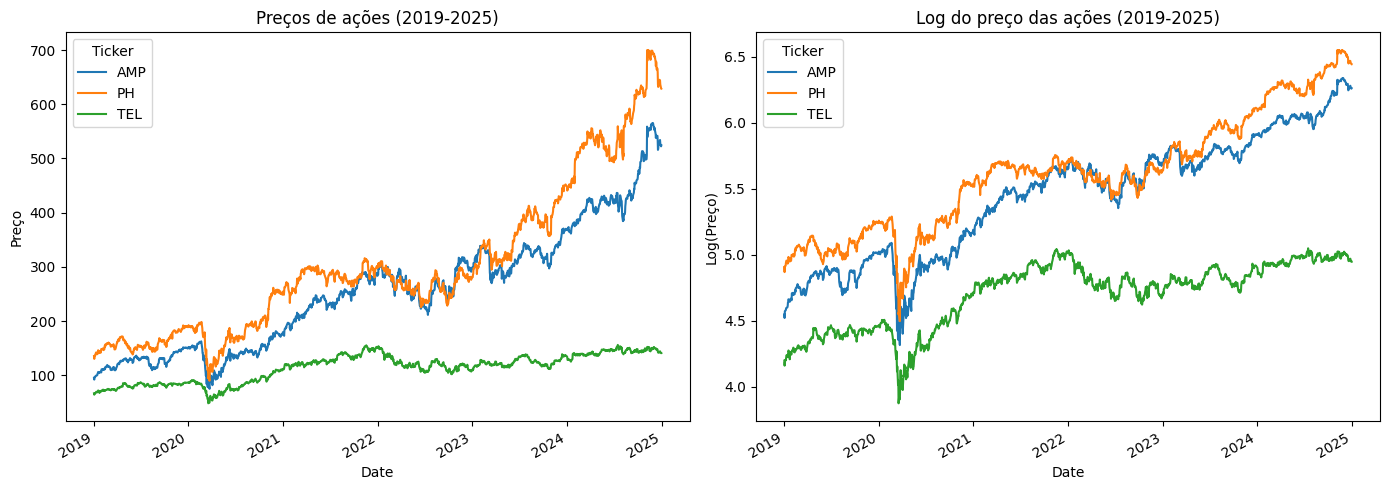

In [16]:
trio = ['AMP', 'PH', 'TEL']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de preços
data[trio].plot(ax=axes[0])
axes[0].set_title('Preços de ações (2019-2025)')
axes[0].set_ylabel('Preço')

# Grafico em log
np.log(data[trio]).plot(ax=axes[1])
axes[1].set_title('Log do preço das ações (2019-2025)')
axes[1].set_ylabel('Log(Preço)')

plt.tight_layout()
plt.show

- Observa-se uma queda abrupta nos preços das ações em **2020**, fortemente associada ao choque causado pela pandemia de **COVID-19**, que gerou elevada incerteza econômica e forte aversão ao risco nos mercados globais.

    Posteriormente, por volta de **2022**, nota-se um período de maior instabilidade, possivelmente relacionado ao ciclo de alta das taxas de juros, adotado por diversos países como resposta ao aumento da inflação, tornando ativos de renda fixa mais atrativos em relação à renda variável.

    A seguir, são apresentados materiais que auxiliam na contextualização e sustentam as observações realizadas.
    
    <https://agencia.ufc.br/pesquisa-avalia-impactos-da-covid-19-no-mercado-financeiro-de-economias-mundiais/?utm_source=chatgpt.com>

    <https://www.cnnbrasil.com.br/economia/financas/um-ano-pos-crash-da-covid-bolsa-tem-acoes-disparando-mas-maioria-amarga-perdas/?utm_source=chatgpt.com>

    <https://g1.globo.com/economia/noticia/2023/01/27/juro-dos-bancos-sobe-82-pontos-em-2022-mais-do-que-a-alta-da-selic-e-credito-bancario-avanca-14percent.ghtml>

    <https://forbes.com.br/forbes-money/2021/10/bancos-passam-a-ver-alta-mais-forte-do-juro-e-taxa-acima-de-10-em-2022/>

Agora que a carteira foi definida com base nos critérios de correlação, torna-se importante compreender melhor os ativos selecionados e suas respectivas áreas de atuação. A seguir, é apresentado um breve resumo das empresas que compõem o portfólio analisado:

- **AMP (Ameriprise Financial)**: empresa do setor financeiro que atua na gestão de investimentos, planejamento financeiro e serviços de consultoria.
- **PH (Parker-Hannifin)**: empresa do setor industrial especializada em tecnologias de controle de movimento e sistemas de engenharia para diversos segmentos da indústria.
- **TEL (TE Connectivity)**: empresa do setor de tecnologia da informação que desenvolve soluções de conectividade e sensores utilizados em indústrias como automotiva, telecomunicações e energia.

Apesar de pertencerem a setores distintos, as empresas selecionadas podem apresentar comportamentos correlacionados devido à influência de fatores macroeconômicos comuns. Elementos como taxas de juros, crescimento econômico global, inflação e nível de atividade industrial impactam simultaneamente diferentes segmentos do mercado.

No caso das empresas analisadas, é possível observar que:

- O setor financeiro **(AMP)** é diretamente influenciado por taxas de juros e pelo desempenho geral da economia;
- O setor industrial **(PH)** depende fortemente da atividade econômica e da demanda por produção;
- O setor de tecnologia **(TEL)**, especialmente em áreas como infraestrutura e indústria, também acompanha ciclos econômicos e investimentos produtivos.

Dessa forma, mesmo atuando em áreas distintas, essas empresas podem reagir de maneira semelhante a mudanças no cenário econômico, o que ajuda a explicar a correlação observada entre seus preços ao longo do tempo.

Após a definição dos ativos que compõem a carteira, inicia-se a etapa de preparação dos dados para a modelagem. Nesse contexto, além dos preços das ações, são adicionados indicadores técnicos que auxiliam na captura de padrões e tendências presentes nas séries temporais. Esses indicadores são amplamente utilizados no mercado financeiro e podem contribuir para melhorar o desempenho dos modelos de previsão.

In [17]:
# Função para adicionar indicadores técnicos às séries de preços
# São calculadas médias móveis (SMA e EMA) e o RSI, que ajudam a capturar tendências e força de movimento dos ativos
def add_indicators(df, col='Close', window=14):
    ticker = col.split('_')[0]
    
    # Média móvel simples
    df[f'{ticker}_SMA_{window}'] = df[col].rolling(window=window).mean()
    
    # Média móvel exponencial
    df[f'{ticker}_EMA_{window}'] = df[col].ewm(span=window, adjust=False).mean()
    
    # Cálculo do RSI (Relative Strength Index)
    delta = df[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    
    df[f'{ticker}_RSI_{window}'] = 100 - (100 / (1 + rs))
    
    return df

- A utilização desses indicadores permite enriquecer o conjunto de dados, oferecendo ao modelo não apenas os preços, mas também informações derivadas que representam tendências e momentos de mercado.

In [18]:
tickers = ['AMP', 'PH', 'TEL']

dfs = []

for t in tickers:
    
    # Baixa os dados históricos da ação
    df = yf.download(t, start='2019-01-01', end='2025-07-31')
    
    # Mantém apenas o preço de fechamento e renomeia a coluna
    df = df[['Close']].rename(columns={'Close': f'{t}_Close'})
    
    # Adiciona indicadores técnicos ao DataFrame
    df = add_indicators(df, col=f'{t}_Close', window=14)
    
    # Armazena o DataFrame na lista
    dfs.append(df)

# Combina os dados de todas as ações em um único DataFrame
data = pd.concat(dfs, axis=1).dropna()

# Ajusta os nomes das colunas (remove possíveis níveis extras)
data.columns = data.columns.get_level_values(0)
data.columns.name = None

# Exibe as últimas linhas do conjunto de dados final
data.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,AMP_Close,AMP_SMA_14,AMP_EMA_14,AMP_RSI_14,PH_Close,PH_SMA_14,PH_EMA_14,PH_RSI_14,TEL_Close,TEL_SMA_14,TEL_EMA_14,TEL_RSI_14
Date,,,,,,,,,,,,
2025-07-24,512.149353,529.650914,527.308789,35.926095,724.968628,710.954960,710.399384,57.249689,204.245316,178.858691,181.527366,88.229496
2025-07-25,516.071411,528.564270,525.810472,41.481778,734.109985,713.242427,713.560797,73.405939,206.689102,181.478458,184.882264,95.851928
2025-07-28,513.486511,527.317749,524.167277,40.467436,734.348389,715.523503,716.332476,73.371110,207.960663,184.097515,187.959384,95.850896
2025-07-29,516.002136,526.010389,523.078592,39.908276,730.175232,717.458941,718.178177,68.861543,207.791794,186.688898,190.603705,95.422875
2025-07-30,514.773987,524.400238,521.971311,37.321736,727.363281,718.717298,719.402858,62.958670,205.318176,188.934715,192.565635,89.258186


- **AMP_Close**, **PH_Close**, **TEL_Close**: preço de fechamento das ações de cada empresa ao final do dia de negociação.
- **SMA_14 (Simple Moving Average)**: média móvel simples considerando uma janela de 14 períodos. Esse indicador suaviza os preços e auxilia na identificação de tendências.
- **EMA_14 (Exponential Moving Average)**: média móvel exponencial com janela de 14 períodos. Diferente da SMA, atribui maior peso aos valores mais recentes, sendo mais sensível a mudanças.
- **RSI_14 (Relative Strength Index)**: indicador de força relativa que varia entre 0 e 100, utilizado para identificar possíveis condições de sobrecompra ou sobrevenda do ativo.

Antes de alimentar os dados no modelo, é necessário realizar a normalização das variáveis. Redes neurais, como **LSTM** e **GRU**, tendem a apresentar melhor desempenho quando os dados estão em uma mesma escala, evitando que variáveis com valores maiores tenham influência desproporcional no treinamento.

Para isso, foi utilizado o `MinMaxScaler`, que transforma os dados para um intervalo entre **0** e **1**, preservando a relação entre os valores originais.

In [19]:
# Normaliza os dados para o intervalo entre 0 e 1, facilitando o treinamento do modelo
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

- Nesta etapa, os dados são reorganizados no formato de sequências temporais para serem utilizados como entrada no modelo. Para cada ponto no tempo, é criada uma janela contendo os valores dos passos anteriores, definida por `seq_len`. O modelo, então, utiliza essas sequências para aprender padrões ao longo do tempo e prever o valor futuro do ativo, sendo neste caso o preço de fechamento do primeiro ativo da série.

In [20]:
def create_multivariate_sequences(data, seq_len):
    X, y = [], []  # listas para armazenar sequências (X) e alvo (y)
    
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])  # janela de seq_len passos anteriores
        y.append(data[i, 0])  # valor alvo: fechamento do primeiro ativo
    
    return np.array(X), np.array(y)  # converte listas para arrays

In [21]:
seq_len = 60  # tamanho da janela temporal (quantidade de passos anteriores)

X, y = create_multivariate_sequences(scaled, seq_len)  # cria sequências de entrada e alvo

# Divisão treino/teste (80% treino, 20% teste)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Exibe os formatos dos dados
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Formato de X: (1579, 60, 12)
Formato de y: (1579,)
Treino: (1263, 60, 12)
Teste: (316, 60, 12)


- Define um dataset personalizado para séries temporais, estruturando os dados de entrada e saída no formato esperado pelo PyTorch para treinamento do modelo.

In [22]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # Converte os dados para tensores do PyTorch
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        # Retorna o tamanho do dataset
        return len(self.X)

    def __getitem__(self, idx):
        # Retorna uma amostra (entrada e alvo)
        return self.X[idx], self.y[idx]

In [23]:
# Cria os datasets de treino e teste
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)

# Cria os DataLoaders para carregar os dados em batches durante o treinamento
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)  # embaralha os dados de treino
test_loader = DataLoader(test_ds, batch_size=32)  # mantém a ordem no teste

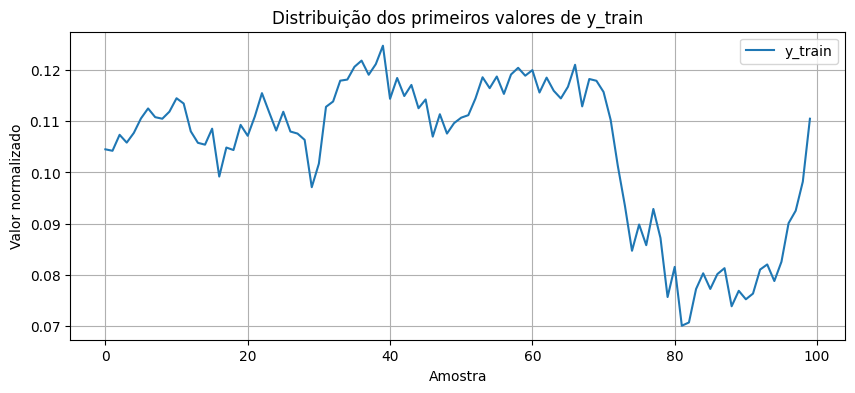

In [24]:
# Verificar se y_train tem variação significativa
plt.figure(figsize=(10, 4))
plt.plot(y_train[:100], label='y_train')
plt.title('Distribuição dos primeiros valores de y_train')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

- O gráfico apresenta a evolução dos primeiros valores da variável alvo (`y_train`) após normalização. Observa-se um comportamento temporal típico de séries financeiras, com períodos de estabilidade, seguido por uma queda acentuada e posterior recuperação. Essa variação é importante para o treinamento do modelo **LSTM**, pois permite que a rede aprenda padrões de tendência e reversão no mercado.

- Nesta etapa, é definido o modelo de deep learning utilizado para a previsão das séries temporais. A arquitetura proposta combina camadas **LSTM** e **GRU**, com o objetivo de capturar padrões de longo prazo e refinar as representações ao longo do tempo. Ao final, uma camada linear é utilizada para gerar a previsão do valor do ativo com base nas informações aprendidas pelo modelo.

In [25]:
class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_lstm=64, hidden_gru=32):
        super().__init__()

        # Camada LSTM: captura padrões temporais de longo prazo
        # input_size: número de variáveis por passo de tempo
        # hidden_lstm: dimensão do estado oculto da LSTM
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_lstm,
            batch_first=True
        )

        # Camada GRU: refina as representações extraídas pela LSTM
        # Recebe como entrada a saída da LSTM
        self.gru = nn.GRU(
            input_size=hidden_lstm,
            hidden_size=hidden_gru,
            batch_first=True
        )

        # Camada totalmente conectada (linear)
        # Converte a saída final da GRU em uma previsão escalar
        self.fc = nn.Linear(hidden_gru, 1)

    def forward(self, x):

        # Passagem pela LSTM
        # out_lstm1: (batch, seq_len, hidden_lstm)
        out_lstm1, _ = self.lstm1(x)

        # Passagem pela GRU
        # out_gru: (batch, seq_len, hidden_gru)
        out_gru, _ = self.gru(out_lstm1)

        # Seleciona apenas o último passo da sequência
        # out_gru[:, -1, :] → (batch, hidden_gru)
        final_output = self.fc(out_gru[:, -1, :])

        return final_output

In [26]:
# Define automaticamente o número de features por timestep (entrada do modelo)
input_size = X_train.shape[2]

# Define o dispositivo de execução (GPU se disponível, senão CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inicializa o modelo e o move para o dispositivo definido
model = LSTM_GRU_Model(input_size=input_size).to(device)

# Define a função de perda (erro quadrático médio, comum em regressão)
criterion = nn.MSELoss()

# Define o otimizador (Adam), responsável por ajustar os pesos do modelo
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

- Nesta etapa, é realizado o treinamento do modelo, utilizando um conjunto de dados de treino e validação. A cada época, o modelo é ajustado com base no erro obtido nos dados de treino, enquanto seu desempenho é avaliado nos dados de validação. Além disso, é armazenada a melhor versão do modelo com base na menor perda de validação, evitando problemas como overfitting. Ao final, são apresentadas as curvas de perda, permitindo analisar o comportamento do modelo ao longo do treinamento.

Epoch  1: Train Loss = 0.018880, Val Loss = 0.003939
Epoch  2: Train Loss = 0.001487, Val Loss = 0.001576
Epoch  3: Train Loss = 0.000897, Val Loss = 0.001382
Epoch  4: Train Loss = 0.000630, Val Loss = 0.001347
Epoch  5: Train Loss = 0.000439, Val Loss = 0.002623
Epoch  6: Train Loss = 0.000370, Val Loss = 0.002193
Epoch  7: Train Loss = 0.000292, Val Loss = 0.002527
Epoch  8: Train Loss = 0.000248, Val Loss = 0.003726
Epoch  9: Train Loss = 0.000250, Val Loss = 0.003257
Epoch 10: Train Loss = 0.000243, Val Loss = 0.003745
Epoch 11: Train Loss = 0.000224, Val Loss = 0.002388
Epoch 12: Train Loss = 0.000205, Val Loss = 0.004636
Epoch 13: Train Loss = 0.000202, Val Loss = 0.002136
Epoch 14: Train Loss = 0.000198, Val Loss = 0.002449
Epoch 15: Train Loss = 0.000214, Val Loss = 0.001108
Epoch 16: Train Loss = 0.000208, Val Loss = 0.001512
Epoch 17: Train Loss = 0.000193, Val Loss = 0.002481
Epoch 18: Train Loss = 0.000189, Val Loss = 0.001900
Epoch 19: Train Loss = 0.000177, Val Loss = 0.

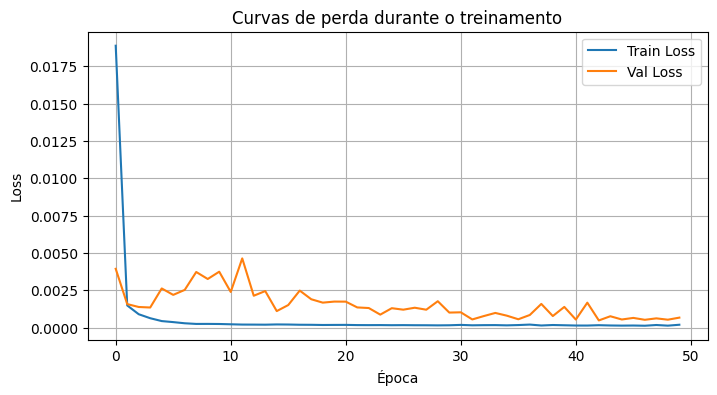

In [27]:
# Treinamento com validação por época e salvamento do melhor modelo
from copy import deepcopy

# Inicializa variáveis de controle
best_val_loss = float('inf')  # melhor erro de validação encontrado
best_model_state = None       # armazenará os pesos do melhor modelo
train_losses, val_losses = [], []  # histórico de perdas

# Loop de treinamento (50 épocas)
for epoch in range(1, 51):
    
    # ===== TREINO =====
    model.train()  # ativa modo de treino (importante para dropout, batchnorm, etc.)
    batch_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()  # zera os gradientes acumulados
        preds = model(xb).squeeze()  # faz previsões
        loss = criterion(preds, yb)  # calcula erro

        loss.backward()  # backpropagation (calcula gradientes)
        optimizer.step()  # atualiza os pesos do modelo

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)  # média da perda no treino

    # ===== VALIDAÇÃO =====
    model.eval()  # modo avaliação (desativa dropout, etc.)
    val_batch_losses = []

    with torch.no_grad():  # desativa cálculo de gradiente (mais eficiente)
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)

            preds = model(xb).squeeze()
            val_loss = criterion(preds, yb)

            val_batch_losses.append(val_loss.item())

    val_loss = np.mean(val_batch_losses)  # média da perda na validação

    # Armazena histórico
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Exibe progresso
    print(f"Epoch {epoch:2d}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

    # Salva o melhor modelo (menor erro de validação)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

# Restaura os pesos do melhor modelo encontrado
model.load_state_dict(best_model_state)

# Plot das curvas de perda
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curvas de perda durante o treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Observa-se que a perda no conjunto de treino se mantém baixa e estável ao longo das épocas, indicando que o modelo foi capaz de aprender os padrões presentes nos dados de treinamento.

Por outro lado, a perda de validação apresenta picos em determinados momentos, comportamento associado à alta volatilidade e ao caráter não estacionário das séries financeiras. Esses picos indicam que o modelo encontra maior dificuldade em prever variações abruptas, especialmente em períodos de mudanças mais intensas no mercado.

Ainda assim, a presença de valores baixos de perda em diversos pontos sugere que o modelo mantém capacidade de generalização, apesar da sensibilidade a eventos mais extremos.

Uma `epoch` corresponde a uma passagem completa do modelo por todos os dados de treino. Durante cada epoch, o modelo processa os dados em pequenos lotes (batches), ajustando seus parâmetros com o objetivo de minimizar o erro.

Ao longo de múltiplas epochs, o modelo aprende progressivamente os padrões presentes nos dados, refinando suas previsões a cada iteração.

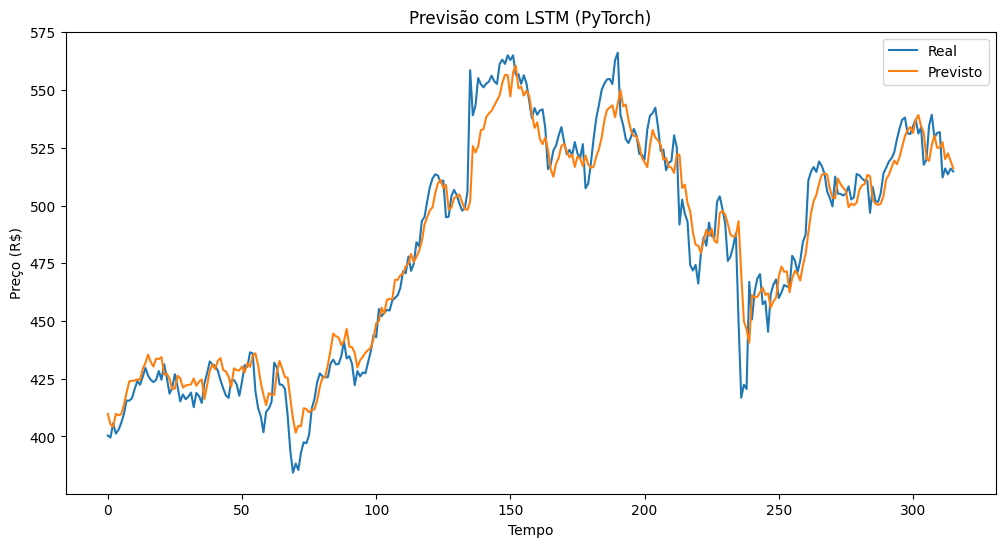

In [28]:
# Coloca o modelo em modo de avaliação
model.eval()

preds = []

# Gera previsões sem calcular gradiente (mais eficiente)
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)  # previsão do modelo
        preds.extend(out.cpu().numpy())  # armazena no CPU

# Converte lista de previsões para array
preds = np.array(preds)

# Cria estruturas completas para aplicar o inverse_transform
# (necessário pois o scaler foi ajustado com múltiplas features)
preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(y_test), scaler.n_features_in_))

# Preenche apenas a coluna do alvo (primeira feature)
preds_full[:, 0] = preds[:, 0]
actual_full[:, 0] = y_test

# Retorna os valores para a escala original
preds_inverse = scaler.inverse_transform(preds_full)[:, 0]
actual_inverse = scaler.inverse_transform(actual_full)[:, 0]

# Plot das previsões vs valores reais
plt.figure(figsize=(12,6))
plt.plot(actual_inverse, label='Real')
plt.plot(preds_inverse, label='Previsto')
plt.legend()
plt.title('Previsão com LSTM (PyTorch)')
plt.xlabel('Tempo')
plt.ylabel('Preço (R$)')
plt.show()

- O gráfico apresentado compara os valores reais do ativo com as previsões geradas pelo modelo ao longo do conjunto de teste. De forma geral, observa-se que o modelo foi capaz de capturar a tendência global da série temporal, acompanhando movimentos de alta e baixa ao longo do período analisado.

    Entretanto, nota-se que as previsões apresentam menor volatilidade em relação aos dados reais, indicando um comportamento mais suavizado. Além disso, em momentos de variações mais abruptas, o modelo demonstra um leve atraso na resposta, não conseguindo reagir imediatamente às mudanças mais intensas do mercado.

    Ainda assim, a proximidade entre as curvas sugere que o modelo conseguiu aprender padrões relevantes dos dados, sendo eficaz na captura de tendências, embora com limitações na previsão de movimentos de curto prazo e alta volatilidade.

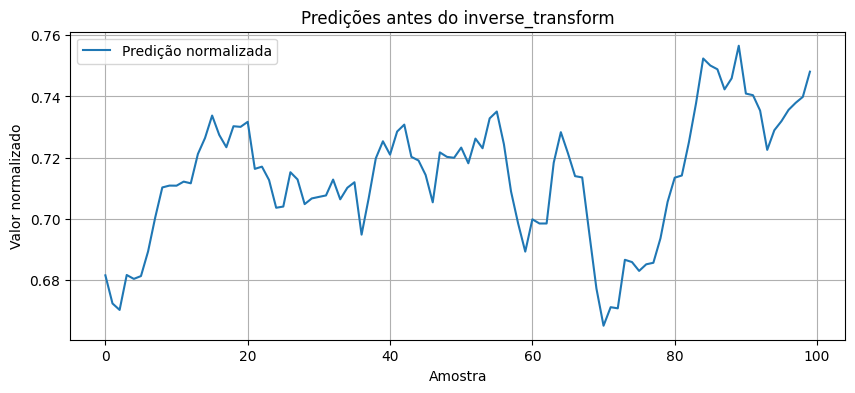

Predição (normalizada) - min: 0.6651, max: 0.9887, média: 0.8277


In [29]:
# Diagnóstico: distribuição das predições normalizadas
plt.figure(figsize=(10, 4))
plt.plot(preds[:100], label='Predição normalizada')
plt.title('Predições antes do inverse_transform')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

print(f"Predição (normalizada) - min: {preds.min():.4f}, max: {preds.max():.4f}, média: {preds.mean():.4f}")

As previsões do modelo, quando analisadas na escala normalizada, concentram-se em uma faixa relativamente estreita, indicando um comportamento conservador. Esse padrão sugere que o modelo tende a suavizar as variações da série temporal, evitando prever valores extremos.

Esse comportamento é consistente com a dificuldade do modelo em capturar movimentos bruscos do mercado, refletindo uma tendência à regressão à média e menor sensibilidade à volatilidade. Além disso, observa-se um leve atraso `(lag)` nas previsões, especialmente em momentos de mudanças mais rápidas, indicando que o modelo demora a reagir a novas dinâmicas do mercado.

Diante dessas limitações, serão realizados alguns ajustes no modelo com o objetivo de torná-lo mais sensível às variações da série temporal. A estrutura geral do código será mantida, porém serão testadas diferentes funções de perda, como `MAE (L1Loss)` e `Huber Loss`, buscando reduzir o efeito de suavização observado.

Além disso, serão incorporadas novas variáveis que capturem melhor a dinâmica de variações abruptas, como retornos percentuais e medidas de volatilidade, com o intuito de melhorar a capacidade do modelo em representar movimentos de alta e baixa de forma mais precisa.

#### Experimento 1: Uso da função de perda MAE

Com base nas limitações observadas no modelo base, como a suavização excessiva das previsões e a baixa sensibilidade a variações bruscas, este experimento propõe a substituição da função de perda **MSE** pela **MAE (Mean Absolute Error)**.

A **MAE** penaliza os erros de forma linear, o que pode tornar o modelo mais sensível a variações reais da série temporal, reduzindo o efeito de suavização observado anteriormente.

A seguir, o modelo será treinado novamente mantendo a mesma estrutura, alterando apenas a função de perda.

In [30]:
# Recriar modelo (IMPORTANTE)
input_size = X_train.shape[2]
model = LSTM_GRU_Model(input_size=input_size).to(device)

# Nova função de perda
criterion = nn.L1Loss()

# Mesmo otimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Treinamento
from copy import deepcopy
best_val_loss = float('inf')
best_model_state = None
train_losses_mae, val_losses_mae = [], []

for epoch in range(1, 51):
    model.train()
    batch_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # Validação
    model.eval()
    val_batch_losses = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).squeeze()
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())

    val_loss = np.mean(val_batch_losses)

    train_losses_mae.append(train_loss)
    val_losses_mae.append(val_loss)

    print(f"[MAE] Epoch {epoch:2d}: Train = {train_loss:.6f}, Val = {val_loss:.6f}")

    # Salvar melhor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

model.load_state_dict(best_model_state)

[MAE] Epoch  1: Train = 0.148281, Val = 0.093603
[MAE] Epoch  2: Train = 0.025508, Val = 0.041891
[MAE] Epoch  3: Train = 0.019122, Val = 0.029157
[MAE] Epoch  4: Train = 0.015598, Val = 0.049022
[MAE] Epoch  5: Train = 0.013069, Val = 0.056549
[MAE] Epoch  6: Train = 0.013105, Val = 0.034097
[MAE] Epoch  7: Train = 0.015228, Val = 0.039910
[MAE] Epoch  8: Train = 0.011505, Val = 0.038150
[MAE] Epoch  9: Train = 0.011331, Val = 0.046155
[MAE] Epoch 10: Train = 0.011440, Val = 0.044943
[MAE] Epoch 11: Train = 0.010929, Val = 0.047920
[MAE] Epoch 12: Train = 0.010685, Val = 0.053909
[MAE] Epoch 13: Train = 0.010560, Val = 0.054180
[MAE] Epoch 14: Train = 0.010288, Val = 0.033288
[MAE] Epoch 15: Train = 0.010836, Val = 0.028698
[MAE] Epoch 16: Train = 0.010426, Val = 0.037727
[MAE] Epoch 17: Train = 0.011646, Val = 0.035732
[MAE] Epoch 18: Train = 0.010811, Val = 0.042563
[MAE] Epoch 19: Train = 0.009609, Val = 0.042151
[MAE] Epoch 20: Train = 0.010931, Val = 0.044063
[MAE] Epoch 21: Trai

<All keys matched successfully>

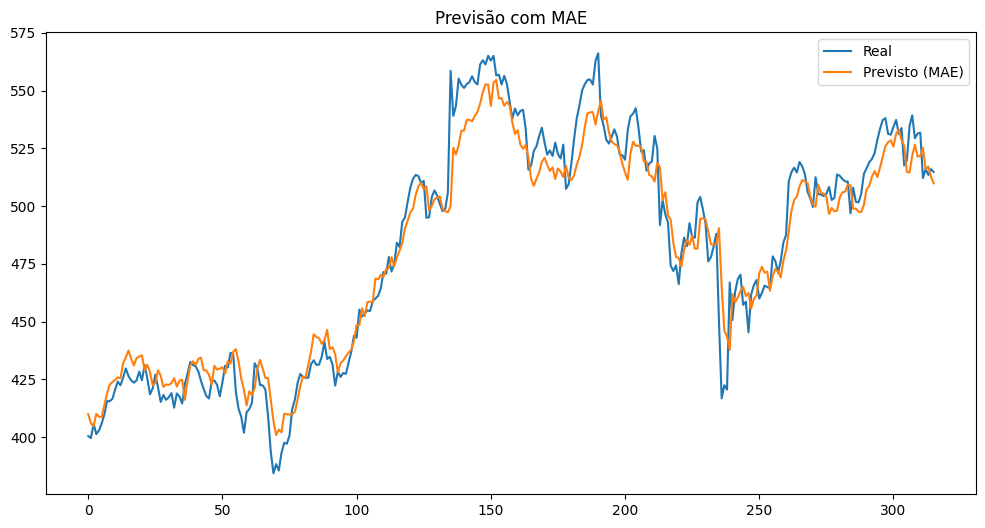

In [31]:
model.eval()
preds = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())

preds = np.array(preds)

preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(y_test), scaler.n_features_in_))

preds_full[:, 0] = preds[:, 0]
actual_full[:, 0] = y_test

preds_inverse_mae = scaler.inverse_transform(preds_full)[:, 0]
actual_inverse_mae = scaler.inverse_transform(actual_full)[:, 0]

# Plot
plt.figure(figsize=(12,6))
plt.plot(actual_inverse_mae, label='Real')
plt.plot(preds_inverse_mae, label='Previsto (MAE)')
plt.legend()
plt.title('Previsão com MAE')
plt.show()

#### Experimento 2: Uso da Huber Loss

A **Huber Loss** combina características da **MSE** e da **MAE**, sendo menos sensível a outliers do que a **MSE** e mais estável que a **MAE**.

Este experimento busca avaliar se a utilização dessa função de perda pode reduzir os picos observados na validação e melhorar a capacidade do modelo em lidar com variações abruptas.

In [32]:
# Recriar modelo
model = LSTM_GRU_Model(input_size=input_size).to(device)

# Huber Loss
criterion = nn.HuberLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')
best_model_state = None
train_losses_huber, val_losses_huber = [], []

for epoch in range(1, 51):
    model.train()
    batch_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    model.eval()
    val_batch_losses = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).squeeze()
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())

    val_loss = np.mean(val_batch_losses)

    train_losses_huber.append(train_loss)
    val_losses_huber.append(val_loss)

    print(f"[Huber] Epoch {epoch:2d}: Train = {train_loss:.6f}, Val = {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

model.load_state_dict(best_model_state)

[Huber] Epoch  1: Train = 0.012804, Val = 0.007476
[Huber] Epoch  2: Train = 0.000777, Val = 0.001032
[Huber] Epoch  3: Train = 0.000453, Val = 0.001526
[Huber] Epoch  4: Train = 0.000359, Val = 0.001361
[Huber] Epoch  5: Train = 0.000283, Val = 0.001763
[Huber] Epoch  6: Train = 0.000214, Val = 0.002801
[Huber] Epoch  7: Train = 0.000159, Val = 0.002049
[Huber] Epoch  8: Train = 0.000150, Val = 0.003983
[Huber] Epoch  9: Train = 0.000138, Val = 0.003338
[Huber] Epoch 10: Train = 0.000127, Val = 0.002157
[Huber] Epoch 11: Train = 0.000127, Val = 0.002226
[Huber] Epoch 12: Train = 0.000141, Val = 0.001656
[Huber] Epoch 13: Train = 0.000122, Val = 0.002570
[Huber] Epoch 14: Train = 0.000117, Val = 0.002067
[Huber] Epoch 15: Train = 0.000112, Val = 0.001945
[Huber] Epoch 16: Train = 0.000109, Val = 0.002686
[Huber] Epoch 17: Train = 0.000117, Val = 0.002401
[Huber] Epoch 18: Train = 0.000108, Val = 0.001653
[Huber] Epoch 19: Train = 0.000119, Val = 0.002342
[Huber] Epoch 20: Train = 0.000

<All keys matched successfully>

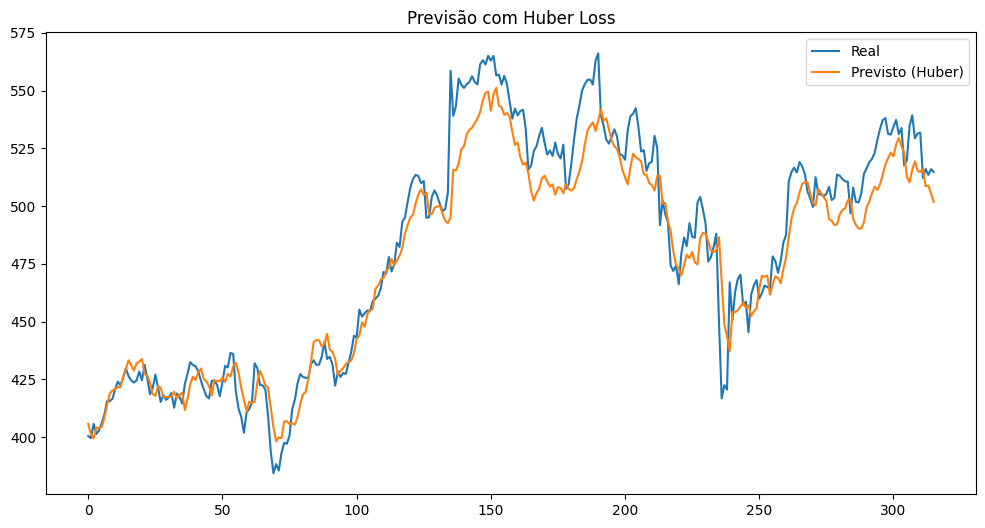

In [33]:
model.eval()
preds = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())

preds = np.array(preds)

preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(y_test), scaler.n_features_in_))

preds_full[:, 0] = preds[:, 0]
actual_full[:, 0] = y_test

preds_inverse_huber = scaler.inverse_transform(preds_full)[:, 0]
actual_inverse_huber = scaler.inverse_transform(actual_full)[:, 0]

# Plot
plt.figure(figsize=(12,6))
plt.plot(actual_inverse_huber, label='Real')
plt.plot(preds_inverse_huber, label='Previsto (Huber)')
plt.legend()
plt.title('Previsão com Huber Loss')
plt.show()

#### Comparação dos Modelos

A seguir, são comparadas as previsões geradas pelos diferentes modelos, permitindo avaliar o impacto das alterações realizadas na função de perda.

Essa análise busca identificar qual abordagem apresentou melhor equilíbrio entre estabilidade e sensibilidade às variações da série temporal.

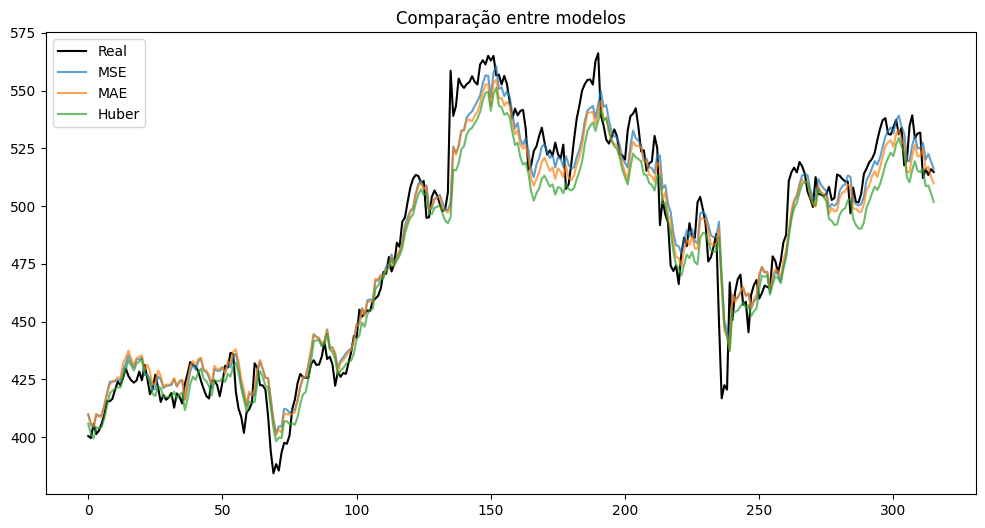

In [34]:
plt.figure(figsize=(12,6))

plt.plot(actual_inverse, label='Real', color='black')
plt.plot(preds_inverse, label='MSE', alpha=0.7)
plt.plot(preds_inverse_mae, label='MAE', alpha=0.7)
plt.plot(preds_inverse_huber, label='Huber', alpha=0.7)

plt.legend()
plt.title('Comparação entre modelos')
plt.show()

#### Análise Comparativa das Funções de Perda

A partir da comparação entre os modelos treinados com **MSE**, **MAE** e **Huber Loss**, observa-se que, embora todos apresentem comportamentos semelhantes na captura da tendência geral, existem diferenças importantes na forma como lidam com as variações da série temporal.

O modelo treinado com **MSE** apresentou previsões mais suavizadas, com menor sensibilidade a picos e quedas abruptas, refletindo sua característica de penalizar fortemente erros maiores.

Já o modelo com **MAE** demonstrou maior capacidade de acompanhar variações mais bruscas, apresentando previsões ligeiramente mais próximas dos movimentos reais. Isso ocorre devido à sua penalização linear dos erros, tornando-o mais sensível às mudanças da série.

Por fim, o modelo com **Huber Loss** apresentou um comportamento intermediário, equilibrando estabilidade e sensibilidade. Observa-se que suas previsões mantêm um bom alinhamento com os dados reais, ao mesmo tempo em que evitam oscilações excessivas.

De forma geral, a **Huber Loss** se mostrou a abordagem mais equilibrada, enquanto a **MAE** apresentou maior responsividade às variações, e a **MSE** maior suavização das previsões.

## Conclusão e Próximos Passos

A partir dos experimentos realizados, observou-se que o modelo proposto, utilizando uma janela temporal de 60 períodos, foi capaz de capturar a tendência geral da série temporal, apresentando bom desempenho na modelagem de movimentos de médio prazo.

A escolha de uma janela menor contribuiu para tornar o modelo mais responsivo às variações recentes dos dados, embora ainda tenham sido identificadas limitações relevantes. Entre elas, destacam-se a dificuldade em capturar movimentos abruptos e a tendência à suavização das previsões, indicando uma sensibilidade limitada à volatilidade do mercado.

A análise comparativa entre diferentes funções de perda mostrou que a MAE apresentou maior capacidade de acompanhar variações mais acentuadas, enquanto a Huber Loss demonstrou um comportamento mais equilibrado entre estabilidade e sensibilidade. Ainda assim, as diferenças observadas entre os modelos foram relativamente sutis.

Dessa forma, conclui-se que as limitações identificadas estão mais relacionadas à representação dos dados do que à escolha da função de perda ou da arquitetura do modelo.

Como proposta de evolução do trabalho, sugere-se a inclusão de novas variáveis que capturem melhor a dinâmica do mercado, como retornos percentuais e medidas de volatilidade, além de possíveis ajustes na definição da variável alvo. Essas melhorias podem contribuir para um modelo mais sensível a variações abruptas e, consequentemente, mais aderente ao comportamento real dos preços.

Essas abordagens são apresentadas como continuidade natural deste estudo.